# BÀI 2 - PHÂN LỚP MỨC ĐỘ GẮN KẾT

Mục tiêu: dự đoán Engagement_Level từ dữ liệu Bài 1.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("../data/processed/dataset_30_attributes_processed.csv")
target = "Engagement_Level"
df = df.dropna(subset=[target]).copy()
y = df[target].astype(str)

class_counts = y.value_counts().rename("Số mẫu")
class_balance = pd.DataFrame({
    "Số mẫu": class_counts,
    "Tỷ lệ (%)": (class_counts / len(y) * 100).round(2),
})
print("Biến mục tiêu:", target)
print("Các lớp:", sorted(y.unique().tolist()))
display(class_balance)
print("Tỷ lệ lớp lớn nhất/nhỏ nhất:", round(class_counts.max() / class_counts.min(), 2))

id_cols = [c for c in ["Viewer_ID", "Live_ID", "Streamer_ID"] if c in df.columns]
X = df.drop(columns=[target] + id_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", encoder),
    ]), categorical_features),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        {"model__C": [0.01, 0.1, 1, 10]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        {
            "model__max_depth": [None, 4, 8, 12],
            "model__min_samples_leaf": [1, 5, 10],
            "model__criterion": ["gini", "entropy"],
        },
    ),
}
searches = {}
for name, (estimator, param_grid) in model_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    search = GridSearchCV(
        pipeline, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, refit=True
    )
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"{name}: CV macro-F1 = {search.best_score_:.4f}")
    print("Siêu tham số tốt nhất:", search.best_params_)

Biến mục tiêu: Engagement_Level
Các lớp: ['High', 'Low', 'Medium']


,Số mẫu,Tỷ lệ (%)
Engagement_Level,,
Medium,6667,33.34
High,6667,33.34
Low,6666,33.33


Tỷ lệ lớp lớn nhất/nhỏ nhất: 1.0
Logistic Regression: CV macro-F1 = 0.9987
Siêu tham số tốt nhất: {'model__C': 0.1}
Decision Tree: CV macro-F1 = 0.9999
Siêu tham số tốt nhất: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1}


## Phạm vi và chuẩn bị dữ liệu

- **Bộ dữ liệu:** `dataset_30_attributes_processed.csv`, là dữ liệu đã tiền xử lý ở Bài 1 theo bộ dữ liệu được duyệt trong ma trận.
- **Biến mục tiêu:** `Engagement_Level`, đại diện cho mức độ gắn kết của người xem.
- **Các lớp:** được in và thống kê ở ô trên; bảng tần suất và tỷ lệ dùng để kiểm tra cân bằng lớp.
- **Mã hóa và co giãn:** biến hạng mục được One-Hot Encoding; biến số được điền trung vị và StandardScaler. Các bước này nằm trong Pipeline và được fit riêng trong từng fold, nên không dùng thông tin từ tập test.
- **Tách dữ liệu:** 80% train và 20% test với `stratify=y`; GridSearch dùng Stratified 5-Fold trên tập train.

## Thuật toán và giả định

- **Logistic Regression:** giả định log-odds của lớp thay đổi gần tuyến tính theo đặc trưng sau mã hóa; các quan sát độc lập. Mạnh ở khả năng giải thích và xác suất dự báo, yếu khi quan hệ phi tuyến.
- **Decision Tree:** không yêu cầu quan hệ tuyến tính hay phân phối chuẩn; tạo luật chia ngưỡng và mô hình hóa tương tác. Dễ diễn giải nhưng dễ overfit và nhạy với dữ liệu.

## Siêu tham số và cách chọn

Dùng GridSearchCV, đánh giá bằng macro-F1 qua 5 fold phân tầng. Logistic Regression thử `C = [0.01, 0.1, 1, 10]`. Decision Tree thử `max_depth = [None, 4, 8, 12]`, `min_samples_leaf = [1, 5, 10]` và `criterion = ['gini', 'entropy']`. Cấu hình có macro-F1 CV cao nhất được refit trên train và đánh giá một lần trên test.

## Độ đo

Accuracy được báo cáo nhưng không dùng một mình khi lớp mất cân bằng. Precision, recall, F1 có cả macro và weighted average; ma trận nhầm lẫn cho từng mô hình. ROC/AUC đa lớp dùng chiến lược One-vs-Rest khi mô hình có xác suất dự báo.

In [5]:
evaluation_rows = []
class_order = sorted(y.unique())

for name, search in searches.items():
    model = search.best_estimator_
    y_pred = model.predict(X_test)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    evaluation_rows.append({
        "Mô hình": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision macro": precision_macro,
        "Recall macro": recall_macro,
        "F1 macro": f1_macro,
        "Precision weighted": precision_weighted,
        "Recall weighted": recall_weighted,
        "F1 weighted": f1_weighted,
        "CV macro-F1": search.best_score_,
    })
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, zero_division=0))
    confusion = confusion_matrix(y_test, y_pred, labels=class_order)
    display(pd.DataFrame(confusion, index=class_order, columns=class_order))

results_df = pd.DataFrame(evaluation_rows).sort_values("F1 macro", ascending=False)
display(results_df.round(4))


===== Logistic Regression =====
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1334
         Low       1.00      1.00      1.00      1333
      Medium       1.00      1.00      1.00      1333

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



,High,Low,Medium
High,1333,0,1
Low,0,1332,1
Medium,6,0,1327



===== Decision Tree =====
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1334
         Low       1.00      1.00      1.00      1333
      Medium       1.00      1.00      1.00      1333

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



,High,Low,Medium
High,1334,0,0
Low,0,1332,1
Medium,0,0,1333


,Mô hình,Accuracy,Precision macro,Recall macro,F1 macro,Precision weighted,Recall weighted,F1 weighted,CV macro-F1
1,Decision Tree,0.9998,0.9998,0.9997,0.9997,0.9998,0.9998,0.9997,0.9999
0,Logistic Regression,0.9980,0.9980,0.9980,0.9980,0.9980,0.9980,0.9980,0.9987


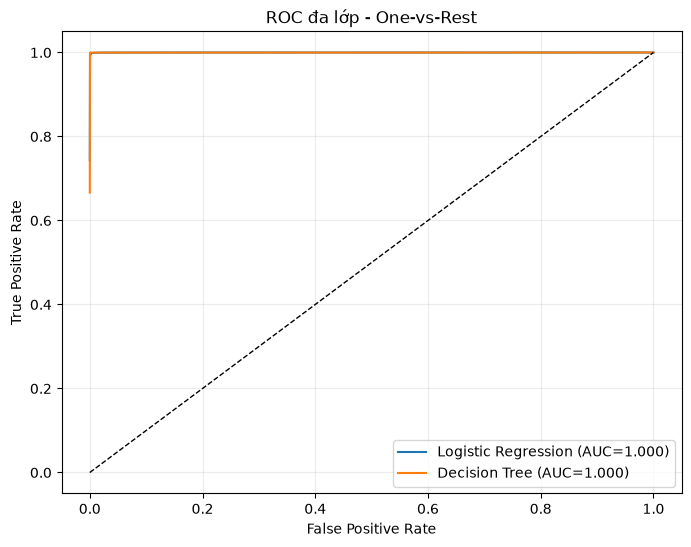

,Mô hình,ROC-AUC macro (OvR),ROC-AUC weighted (OvR)
0,Logistic Regression,0.9998,0.9998
1,Decision Tree,0.9998,0.9998


In [4]:
# ROC/AUC đa lớp theo chiến lược One-vs-Rest.
y_test_binary = label_binarize(y_test, classes=class_order)
auc_rows = []
plt.figure(figsize=(8, 6))

for name, search in searches.items():
    y_score = search.best_estimator_.predict_proba(X_test)
    macro_auc = roc_auc_score(
        y_test, y_score, multi_class="ovr", average="macro", labels=class_order
    )
    weighted_auc = roc_auc_score(
        y_test, y_score, multi_class="ovr", average="weighted", labels=class_order
    )
    auc_rows.append({
        "Mô hình": name,
        "ROC-AUC macro (OvR)": macro_auc,
        "ROC-AUC weighted (OvR)": weighted_auc,
    })

    false_positive_rate = {}
    true_positive_rate = {}
    for index, class_name in enumerate(class_order):
        false_positive_rate[class_name], true_positive_rate[class_name], _ = roc_curve(
            y_test_binary[:, index], y_score[:, index]
        )
    all_fpr = np.unique(
        np.concatenate([false_positive_rate[class_name] for class_name in class_order])
    )
    mean_tpr = sum(
        np.interp(all_fpr, false_positive_rate[class_name], true_positive_rate[class_name])
        for class_name in class_order
    ) / len(class_order)
    plt.plot(all_fpr, mean_tpr, label=f"{name} (AUC={macro_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC đa lớp - One-vs-Rest")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
display(pd.DataFrame(auc_rows).round(4))